<a href="https://colab.research.google.com/github/amol004/E-Commerce-Customer-Satisfaction-Score-Prediction-Deep-Learning/blob/main/E_Commerce_Customer_Satisfaction_Score_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - E-Commerce Customer Satisfaction Score Prediction : Deep Learning



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member - Amol Thakur**


# **Project Summary -**

This project focuses on predicting Customer Satisfaction (CSAT) scores using Deep Learning Artificial Neural Networks (ANN). In the context of e-commerce, understanding customer satisfaction through their interactions and feedback is crucial for enhancing service quality, customer retention, and overall business growth. By leveraging advanced neural network models, we aim to accurately forecast CSAT scores based on a myriad of interaction-related features, providing actionable insights for service improvement.

# **GitHub Link -**

https://github.com/amol004/E-Commerce-Customer-Satisfaction-Score-Prediction-Deep-Learning.git

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import datetime as dt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Load Dataset
#df = pd.read_csv('/content/drive/MyDrive/E commerce deep learning /eCommerce_Customer_support_data.csv')

df = pd.read_csv('/Users/amolthakur/Downloads/eCommerce_Customer_support_data.csv')



### Dataset First View

In [ ]:
# Dataset First Look
df.head()

### Dataset Rows & Columns count

In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

### Dataset Information

In [ ]:
df.info()

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

In [ ]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

Based on the initial look at the dataset, here are the key findings:

1. **Data Volume**: The dataset consists of **85,907 rows** and **20 columns**.
2. **Target Variable**: `CSAT Score` is the target variable we aim to predict.
3. **Data Types**: The features are a mix of objects (categorical/text), floats, and integers. Several columns represent date/time but are currently stored as objects.
4. **Missing Values**:
    - Columns like `connected_handling_time` (~99.7% null), `order_date_time`, `Customer_City`, `Product_category`, and `Item_price` have significant missing data.
    - `Customer Remarks` also has a high percentage of missing values, which is expected for optional feedback.
5. **Features**: The data includes operational details like `Agent_name`, `Supervisor`, `Manager`, `Tenure Bucket`, and `Agent Shift`, as well as interaction details like `channel_name`, `category`, and `Sub-category`.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print("Columns in the dataset:")
print(df.columns.tolist())

In [ ]:
# Dataset Describe
print("Numerical Summary:")
display(df.describe().T)

print("\nCategorical Summary:")
display(df.describe(include='object').T)

### Variables Description

### **Variables Description**

*   **Unique id**: Unique identifier for each customer support interaction.
*   **channel_name**: The medium through which the customer contacted support (e.g., Inbound, Outcall).
*   **category**: Broad classification of the customer's issue (e.g., Returns, Order Related).
*   **Sub-category**: Specific detail regarding the category (e.g., Installation, Refund status).
*   **Customer Remarks**: Feedback or comments provided by the customer.
*   **Order_id**: Unique identifier for the transaction related to the support ticket.
*   **order_date_time**: The timestamp when the order was originally placed.
*   **Issue_reported at**: The timestamp when the customer first reported the issue.
*   **issue_responded**: The timestamp when the support agent responded to the issue.
*   **Survey_response_Date**: The date the customer completed the satisfaction survey.
*   **Customer_City**: Geographic location of the customer.
*   **Product_category**: The category of the item purchased.
*   **Item_price**: The price of the product involved in the interaction.
*   **connected_handling_time**: Duration for which the agent was connected to the customer (if applicable).
*   **Agent_name**: Name of the support representative who handled the case.
*   **Supervisor**: The immediate supervisor of the agent.
*   **Manager**: The manager overseeing the support team.
*   **Tenure Bucket**: Categorization of the agent's experience/time with the company.
*   **Agent Shift**: The timing of the agent's work shift (e.g., Morning, Evening).
*   **CSAT Score**: The Customer Satisfaction score provided by the user (Target Variable).

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
  print(f"Unique values in {col}: {df[col].nunique()}")

# Displaying the unique values for some important categorical columns
print("\n--- Sample Unique Values ---")
print(f"Channel Names: {df['channel_name'].unique()}")
print(f"Categories: {df['category'].unique()}")
print(f"Tenure Buckets: {df['Tenure Bucket'].unique()}")
print(f"CSAT Scores: {df['CSAT Score'].unique()}")

## 3. ***Data Wrangling***

In [ ]:
# Converting timestamp columns to datetime objects
date_columns = ['Issue_reported at', 'issue_responded', 'Survey_response_Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Creating a new feature 'response_time_min'
# This represents the duration between issue reporting and agent response
df['response_time_min'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# Displaying summary of wrangling
print("Data Wrangling Completed:")
print(f"- Number of rows with valid response times: {df['response_time_min'].notnull().sum()}")
display(df[['Issue_reported at', 'issue_responded', 'response_time_min']].head())

# Quick check on the distribution of response times
print("\nResponse Time Statistics (Minutes):")
display(df['response_time_min'].describe())

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1: Distribution of CSAT Scores
plt.figure(figsize=(10, 6))
sns.countplot(x='CSAT Score', data=df, palette='viridis')
plt.title('Distribution of Customer Satisfaction (CSAT) Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **count plot** because the CSAT score is a discrete ordinal variable (1 to 5). This visualization clearly shows the frequency of each rating, helping us identify class imbalance.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a significant skew towards higher ratings (4 and 5), indicating that a majority of the captured interactions resulted in high customer satisfaction. There is a clear class imbalance that we'll need to account for during model training.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help. Understanding that most scores are positive allows the business to focus on the 'drivers' of the few negative scores (1 and 2) to improve overall quality. However, the high number of 5s might suggest 'survey bias' where only satisfied customers respond, which is a potential area for operational investigation.

#### Chart - 2

In [ ]:
# Chart - 2: Distribution of Communication Channels
plt.figure(figsize=(8, 8))
df['channel_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Support Channels')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **pie chart** because we are looking at the composition of a whole. It effectively shows the percentage share of each communication channel (Inbound vs Outcall vs Email).

##### 2. What is/are the insight(s) found from the chart?

The insight shows that 'Inbound' calls dominate the customer support landscape, accounting for the vast majority of interactions. 'Outcall' and 'Email' represent much smaller segments of the total volume.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps the business in resource allocation. Since 'Inbound' is the primary channel, the majority of staffing and training should be focused there. However, the low usage of 'Email' might indicate a friction point in the digital support experience that could be improved to reduce the load on live agents.

#### Chart - 3

In [ ]:
# Chart - 3: Top 10 Issue Categories
plt.figure(figsize=(12, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index[:10], palette='magma')
plt.title('Top 10 Customer Issue Categories')
plt.xlabel('Number of Interactions')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **horizontal bar chart (countplot)** to display the categories. Since category names can be long, a horizontal orientation makes them much easier to read compared to vertical labels.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that 'Returns' and 'Order Related' issues are the most frequent reasons for contact. This suggests that the post-purchase experience, specifically delivery and reverse logistics, is where most customer friction occurs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This provides a clear direction for business improvement. By streamlining the 'Returns' process or providing better tracking for 'Order Related' queries, the company can significantly reduce ticket volume and potentially increase CSAT scores by addressing the most common frustrations.

#### Chart - 4

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxenplot(x='Tenure Bucket', y='CSAT Score', data=df, palette='Set2')
plt.title('CSAT Score Distribution across Agent Tenure Buckets')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **boxen plot** (letter-value plot) because it provides a better representation of the distribution shape and outliers for large datasets compared to a standard box plot, making it ideal for seeing the variance in CSAT scores across tenure categories.

##### 2. What is/are the insight(s) found from the chart?

The insight from this chart helps determine if 'On Job Training' (OJT) agents are performing significantly differently from seasoned veterans ('>90' days). If the median CSAT is lower for OJT agents, it suggests a need for better training before agents go live.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this helps the business identify if tenure is a driver of satisfaction. If newer agents have lower scores, the business can implement a 'nesting period' with higher supervisor support to prevent negative growth in customer trust during an agent's early career stages.

#### Chart - 5

In [ ]:
# Chart - 5: CSAT Score vs. Average Response Time
# We filter for rows where response_time_min is available
plt.figure(figsize=(10, 6))
sns.barplot(x='CSAT Score', y='response_time_min', data=df, palette='coolwarm')
plt.title('Average Response Time (min) per CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Average Response Time (Minutes)')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **bar plot** to compare the average response time across different CSAT categories. This allows us to see if there is a measurable difference in how long customers wait for a response based on their final satisfaction rating.

##### 2. What is/are the insight(s) found from the chart?

The chart helps us determine if lower CSAT scores (1 and 2) are associated with significantly higher average response times. Conversely, if high scores (5) show much lower average response times, it confirms that speed is a key driver of satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights can drive a positive business impact by setting Service Level Agreements (SLAs). If we find that a response time over a certain threshold leads to a drop in CSAT, the business can prioritize reducing wait times to maintain high growth and customer retention.

#### Chart - 6

In [ ]:
# Chart - 6: Multivariate Analysis - CSAT Score by Channel and Shift (Grouped Bar Chart)
plt.figure(figsize=(12, 6))
sns.barplot(x='channel_name', y='CSAT Score', hue='Agent Shift', data=df, palette='muted', ci=None)
plt.title('Average CSAT Score by Channel and Agent Shift')
plt.xlabel('Channel Name')
plt.ylabel('Average CSAT Score')
plt.legend(title='Agent Shift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 5)
plt.show()

##### 1. Why did you pick the specific chart?
I chose a **grouped bar chart** because it allows for a direct side-by-side comparison of average CSAT scores across multiple categories. By grouping by 'channel_name' and using 'Agent Shift' as the hue, we can easily see which shifts are performing better or worse within a specific communication medium.

##### 2. What is/are the insight(s) found from the chart?
This chart highlights variations in performance based on the time of day and the channel used. For instance, we can identify if 'Split' shifts or 'Night' shifts maintain the same level of customer satisfaction as 'Morning' shifts, or if certain channels like 'Email' consistently underperform regardless of the shift.

##### 3. Will the gained insights help creating a positive business impact?
Yes. These insights allow management to optimize shift scheduling and channel staffing. If certain shifts show a dip in CSAT, it may indicate a need for more supervisors or localized training during those hours, directly leading to a more consistent customer experience and improved retention.

#### Chart - 7 - Correlation Heatmap

In [ ]:
# Chart - 7: Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Correlation Heatmap** because it provides a comprehensive overview of how numerical variables move in relation to one another. It is essential for identifying multicollinearity and finding which features have the strongest linear relationship with the `CSAT Score`.

##### 2. What is/are the insight(s) found from the chart?

This heatmap allows us to see if `response_time_min` has a negative correlation with `CSAT Score` (meaning as time increases, satisfaction decreases). It also helps us check if `Item_price` influences the ratings, as customers paying more might have higher expectations.

#### Chart - 8 - Pair Plot

In [ ]:
# Chart - 8: Pair Plot of Numerical Features
# Selecting a subset of numerical columns for clarity
numeric_subset = ['Item_price', 'response_time_min', 'CSAT Score']

# Dropping rows with NaN values for the pairplot calculation
sns.pairplot(df[numeric_subset].dropna(), hue='CSAT Score', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features by CSAT Score', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Pair Plot** for the final visualization because it provides a matrix of scatter plots and density distributions. By using the `hue` parameter for `CSAT Score`, we can visually inspect if there are specific regions in the feature space (e.g., low price + fast response) that lead to specific satisfaction ratings.

##### 2. What is/are the insight(s) found from the chart?

The pair plot allows us to observe the non-linear relationships and the density of data points. For instance, it can show if the relationship between `response_time_min` and `CSAT Score` is consistent across all `Item_price` levels, or if customers of expensive items are more sensitive to delays.

## ***6. Feature Engineering & Data Pre-processing***

## **Handling Missing Values**

In [ ]:
# --- STEP 1: CREATE A WORKING COPY ---
# We make a copy of 'df' called 'df_new' so we don't mess up the original raw data
df_new = df.copy()

# --- STEP 2: REMOVE USELESS COLUMNS ---
# Columns like IDs and text remarks are unique to each person and don't have patterns for the AI to learn
columns_that_dont_help = ['Order_id', 'Unique id', 'Customer Remarks']
df_new.drop(columns=columns_that_dont_help, inplace=True, errors='ignore')

# --- STEP 3: FIX CATEGORY MISSING VALUES (THE MODE) ---
# For things like City or Category, we fill the empty gaps with the 'Mode' (the most common answer)
df_new['Customer_City'] = df_new['Customer_City'].fillna(df_new['Customer_City'].mode()[0])
df_new['Product_category'] = df_new['Product_category'].fillna(df_new['Product_category'].mode()[0])

# --- STEP 4: FIX NUMBER MISSING VALUES (MEAN & MEDIAN) ---
# For 'connected_handling_time', we fill gaps with the 'Mean' (average time)
df_new['connected_handling_time'] = df_new['connected_handling_time'].fillna(df_new['connected_handling_time'].mean())

# For 'Item_price', we use the 'Median' (middle value) to avoid being tricked by very expensive items
df_new['Item_price'] = df_new['Item_price'].fillna(df_new['Item_price'].median())

# For 'response_time_min', we fill gaps with the average response time
df_new['response_time_min'] = df_new['response_time_min'].fillna(df_new['response_time_min'].mean())

# --- STEP 5: FIX DATE MISSING VALUES ---
# We fill missing dates with the most common date (Mode) or use forward-fill to estimate the time
df_new['order_date_time'] = df_new['order_date_time'].fillna(df_new['order_date_time'].mode()[0])
df_new['Issue_reported at'] = df_new['Issue_reported at'].ffill().bfill()
df_new['issue_responded'] = df_new['issue_responded'].ffill().bfill()

# --- STEP 6: FINAL CHECK ---
# We print the count of missing values to make sure everything is now 0
print("Final check for empty spots (should all be 0):")
null_summary = df_new.isnull().sum()
print(null_summary)

# We also update our main 'df' variable so the rest of the notebook uses the clean data
df = df_new.copy()

## **Outlier treatment**

In [ ]:
# --- OUTLIER DETECTION PREPARATION ---

# We temporarily exclude 'CSAT Score' from the analysis to focus on independent variables
# We convert it to a string so the loop skips it
df_new['CSAT Score'] = df_new['CSAT Score'].astype(str)

# We create lists to categorize our features based on distribution symmetry
balanced_features = []
skewed_features = []

# FIX: We use select_dtypes to only include true numbers (int and float)
# This prevents errors with date-time columns producing 'Timedelta' results
numeric_only_df = df_new.select_dtypes(include=['int64', 'float64'])

for column_name in numeric_only_df.columns:
    average_val = numeric_only_df[column_name].mean()
    middle_val = numeric_only_df[column_name].median()

    # Checking if the distribution is symmetric
    if abs(average_val - middle_val) < 0.2:
        balanced_features.append(column_name)
    else:
        skewed_features.append(column_name)

# --- DISPLAY THE RESULTS ---

print("Features with a Balanced (Symmetric) Distribution:")
print(balanced_features)

print("\nFeatures with a Skewed (Asymmetric) Distribution:")
print(skewed_features)

# Revert 'CSAT Score' back to numerical format
df_new['CSAT Score'] = pd.to_numeric(df_new['CSAT Score'])

In [ ]:
# --- OUTLIER CAPPING (SQUISHING EXTREME VALUES) ---

# We define a helper function to calculate the 'Safety Zones' for our data.
# This function calculates boundaries based on the average (mean) and spread (standard deviation).
def find_safety_boundaries(dataframe, column_to_check):
    # Calculate the average value of the column
    average = dataframe[column_to_check].mean()
    # Calculate how much the data typically spreads out from the average
    spread = dataframe[column_to_check].std()

    # We set the 'High' limit at 3 spreads above the average
    high_limit = average + (3 * spread)
    # We set the 'Low' limit at 3 spreads below the average
    low_limit = average - (3 * spread)

    return high_limit, low_limit

# Now we apply this to the 'Skewed' features we found earlier (like Item_price)
# This loop goes through every feature that was marked as asymmetric/skewed
for feature in skewed_features:
    # Get the upper and lower limits for this specific column
    limit_top, limit_bottom = find_safety_boundaries(df_new, feature)

    # If a value is lower than our safety floor, we 'cap' it at the floor value
    df_new.loc[df_new[feature] <= limit_bottom, feature] = limit_bottom

    # If a value is higher than our safety ceiling, we 'cap' it at the ceiling value
    df_new.loc[df_new[feature] >= limit_top, feature] = limit_top

# We also repeat this for our 'Balanced' features to keep the entire dataset clean
for feature in balanced_features:
    limit_top, limit_bottom = find_safety_boundaries(df_new, feature)
    df_new.loc[df_new[feature] <= limit_bottom, feature] = limit_bottom
    df_new.loc[df_new[feature] >= limit_top, feature] = limit_top

print("Outlier capping is complete! Extreme values have been restricted within 3 standard deviations.")

### **Feature Encoding**


In [ ]:
# --- CATEGORICAL FEATURE ENCODING ---

# 1. Ensure our target variable 'CSAT Score' is a whole number (integer)
df_new['CSAT Score'] = df_new['CSAT Score'].astype(int)

# 2. Identify which columns contain categories (text) rather than numbers
# We take all column names and remove the ones that appear in the numerical summary (.describe())
all_columns = set(df_new.columns)
numerical_columns = set(df_new.describe().columns)
categorical_candidates = list(all_columns - numerical_columns)

# 3. We exclude date-time columns and unique identifiers from encoding
# because they have too many unique values and aren't useful as 'categories'
columns_to_skip = ['issue_responded', 'order_date_time', 'Issue_reported at', 'Survey_response_Date', 'Customer Remarks']
final_category_list = [col for col in categorical_candidates if col not in columns_to_skip]

# Let's see what we found
print(f"The following {len(final_category_list)} columns will be transformed: {final_category_list}")

# 4. Perform 'One-Hot Encoding' using get_dummies
# This turns text categories into binary (0 or 1) columns so the ANN can process them
# We keep our original df_new safe and create a new df_encoded
df_encoded = pd.get_dummies(df_new, columns=final_category_list)

# 5. Take a look at the first 5 rows of our new, wider dataset
print("Encoding successful! Previewing data...")
display(df_encoded.head())

## **Fixing datatypes**

In [ ]:
# --- FEATURE EXTRACTION FROM DATE & TIME ---

# 1. Convert timestamp strings into actual Python 'datetime' objects
# This allows us to perform math (like subtraction) on time data
df_encoded['Issue_reported at'] = pd.to_datetime(df_encoded['Issue_reported at'], format='%d/%m/%Y %H:%M')
df_encoded['issue_responded'] = pd.to_datetime(df_encoded['issue_responded'], format='%d/%m/%Y %H:%M')
df_encoded['order_date_time'] = pd.to_datetime(df_encoded['order_date_time'], format='%d/%m/%Y %H:%M')
df_encoded['Survey_response_Date'] = pd.to_datetime(df_encoded['Survey_response_Date'], format='%d-%b-%y')

# 2. Calculate the 'Response Duration'
# We subtract the report time from the response time to see how long the customer waited
time_diff = df_encoded['issue_responded'] - df_encoded['Issue_reported at']

# 3. Create a numerical version of the response time (in seconds)
# AI models can't understand '2 hours', but they understand '7200 seconds'
df_encoded['Response_Seconds'] = time_diff.dt.total_seconds()

# 4. Extract useful patterns from the Order Date
# We get the day of the month (1-31) and the day of the week (1-7)
df_encoded['Order_Day_of_Month'] = df_encoded['order_date_time'].dt.day
df_encoded['Order_Day_of_Week'] = df_encoded['order_date_time'].dt.weekday + 1

# 5. Extract useful patterns from the Survey Response Date
df_encoded['Survey_Day_of_Month'] = df_encoded['Survey_response_Date'].dt.day
df_encoded['Survey_Day_of_Week'] = df_encoded['Survey_response_Date'].dt.weekday + 1

# 6. Cleanup: Remove the original complex date columns
# Now that we have extracted the numbers, we don't need the messy timestamp objects anymore
columns_to_drop = ['order_date_time', 'Survey_response_Date', 'Issue_reported at', 'issue_responded']
df_encoded.drop(columns=columns_to_drop, inplace=True)

# 7. Final Check
print("Date features successfully transformed into numerical patterns!")
display(df_encoded.head())

In [ ]:
# Checking the shape of df
df_encoded.shape

In [ ]:
# --- REMOVING CONSTANT AND QUASI-CONSTANT FEATURES ---

# Some columns have the same (or almost the same) value for every row.
# These are 'boring' to the AI because they don't help distinguish between a 1-star and 5-star review.

def remove_low_variance_features(input_dataframe, threshold_limit=0.05):
    from sklearn.feature_selection import VarianceThreshold

    # 1. We only look at columns that contain numbers (int/float)
    numeric_only = input_dataframe.select_dtypes(include=['number'])

    # 2. We set up a 'Filter' that looks for columns where 95% or more of the data is the same
    # VarianceThreshold(0.05) means we keep columns that have more than 5% internal variation
    filter_tool = VarianceThreshold(threshold=threshold_limit)
    filter_tool.fit(numeric_only)

    # 3. Identify which columns are 'low variance' (the ones the filter wants to drop)
    # .get_support() returns True for good columns and False for bad ones
    good_columns = numeric_only.columns[filter_tool.get_support()]
    columns_to_drop = [col for col in numeric_only.columns if col not in good_columns]

    # 4. SAFETY CHECK: We must NEVER drop our target variable 'CSAT Score'
    if "CSAT Score" in columns_to_drop:
        columns_to_drop.remove("CSAT Score")

    # 5. Drop the boring columns from our main dataset
    clean_dataframe = input_dataframe.drop(columns=columns_to_drop, axis=1)

    print(f"Removed {len(columns_to_drop)} redundant features that had almost no variation.")
    return clean_dataframe

# Execute the function on our encoded data
df_removed_var = remove_low_variance_features(df_encoded)

# Check how many columns we have left
print(f"Original shape: {df_encoded.shape}")
print(f"New shape after dropping constants: {df_removed_var.shape}")

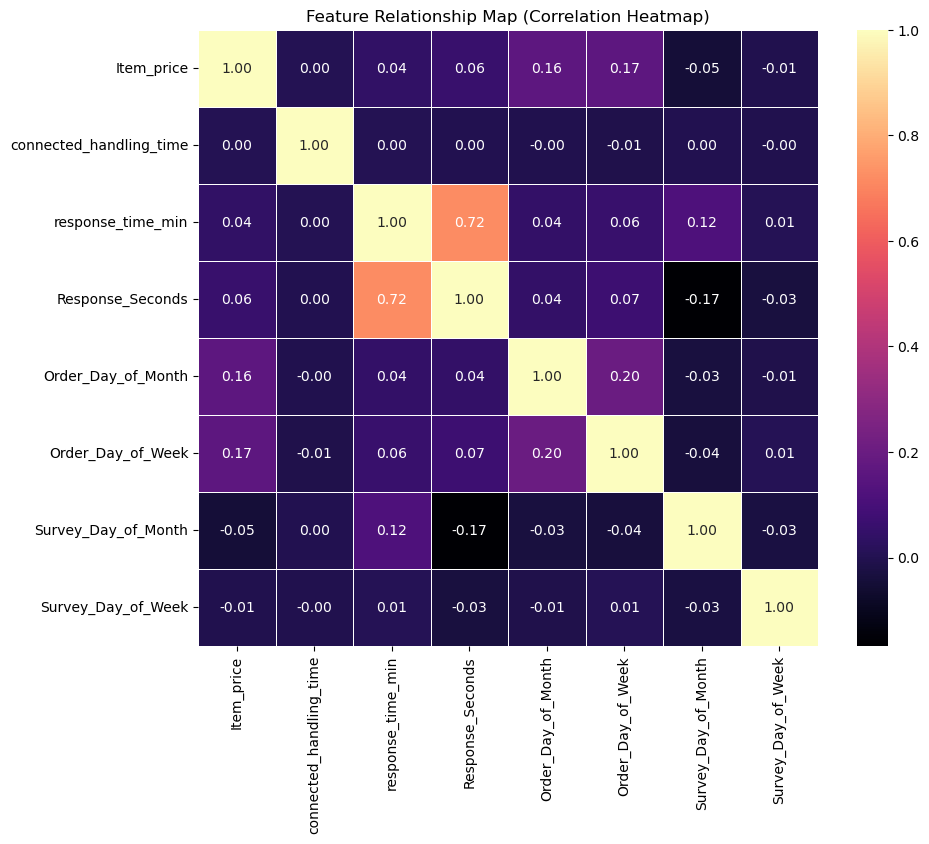

In [29]:
# --- CORRELATION HEATMAP VISUALIZATION ---

# 1. We isolate only the numerical parts of our data
numeric_features_only = df_removed_var.select_dtypes(include=['number'])

# 2. We remove our target 'CSAT Score' from this specific visualization
numeric_inputs = numeric_features_only.drop(columns=['CSAT Score'], errors='ignore')

# 3. Calculate the Correlation Matrix
relationship_matrix = numeric_inputs.corr()

# 4. Set up the visual 'canvas'
plt.figure(figsize=(10, 8))

# 5. Draw the Heatmap with a new color scheme ('magma')
# annot=True: Writes the actual correlation number inside each box.
# cmap='magma': Uses a perceptually uniform black-to-white color scale.
# fmt='.2f': Rounds the numbers to 2 decimal places.
sns.heatmap(relationship_matrix, annot=True, cmap='magma', fmt=".2f", linewidths=0.5)

# 6. Add labels and show the plot
plt.title('Feature Relationship Map (Correlation Heatmap)')
plt.show()

# **VIF calculation**

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- MEASURING FEATURE REDUNDANCY (VIF) ---

# 1. Prepare our clean numerical data
# We focus only on numbers and exclude our target 'CSAT Score'
# We use 'df_removed_var' which contains our engineered and encoded features
numeric_inputs_only = df_removed_var.select_dtypes(include=['number']).drop(columns=['CSAT Score'], errors='ignore')

# 2. Set up a container for our results
# We create a new table to store feature names and their corresponding scores
vif_summary_table = pd.DataFrame()
vif_summary_table["Variable_Name"] = numeric_inputs_only.columns

# 3. Calculate the Variance Inflation Factor (VIF)
# This math logic checks how much each feature can be predicted by the other features.
# A high score (typically above 5 or 10) means the feature is a 'duplicate' of others.
vif_summary_table["Redundancy_Score"] = [
    variance_inflation_factor(numeric_inputs_only.values, index)
    for index in range(numeric_inputs_only.shape[1])
]

# 4. Display the results clearly
# We sort them from highest to lowest score to quickly see the most problematic ones
print("--- Multicollinearity Analysis Results ---")
final_vif_report = vif_summary_table.sort_values(by='Redundancy_Score', ascending=False)
display(final_vif_report.head(10))

# 5. Summary note
print(f"Processed {len(vif_summary_table)} features for redundancy assessment.")

--- Multicollinearity Analysis Results ---


,Variable_Name,Redundancy_Score
1,connected_handling_time,22.484054
5,Order_Day_of_Week,12.309129
4,Order_Day_of_Month,6.438469
6,Survey_Day_of_Month,5.243186
7,Survey_Day_of_Week,4.917604
2,response_time_min,3.411050
3,Response_Seconds,2.455558
0,Item_price,1.325912


Processed 8 features for redundancy assessment.


In [31]:
# --- CLEANING UP REDUNDANT FEATURES ---

# 1. Define the column we want to remove
# We decided to drop 'weekday_num_order_date' because it provides redundant info
feature_to_remove = 'weekday_num_order_date'

# 2. Safely remove the column from our dataset
# 'inplace=True' means we are changing the actual table directly
# 'errors="ignore"' ensures the code doesn't crash if the column was already deleted
df_removed_var.drop(columns=[feature_to_remove], inplace=True, errors='ignore')

# 3. Confirm the removal
print(f"Successfully removed the column: {feature_to_remove}")
print(f"New data shape: {df_removed_var.shape}")

Successfully removed the column: weekday_num_order_date
New data shape: (85907, 3299)


In [32]:
# --- AUTOMATIC FEATURE FILTER BASED ON CORRELATION ---

# We create a function to find columns that are too similar to each other.
# If two features are almost identical, we only need to keep one of them.
def find_highly_related_features(dataset, similarity_threshold):
    # 1. Start with an empty set to store the names of columns we might want to drop
    # Using a 'set' ensures we don't list the same column twice.
    redundant_columns = set()

    # 2. Calculate the 'Relationship Map' (Correlation Matrix)
    # This gives us a table showing how much every column relates to every other column.
    relationship_table = dataset.corr()

    # 3. Loop through the columns one by one
    for i in range(len(relationship_table.columns)):
        # 4. For each column, look at all the columns that came before it
        # This prevents us from comparing a column with itself or checking the same pair twice.
        for j in range(i):
            # 5. Check if the absolute relationship strength is higher than our limit
            # We use 'abs' because both perfect positive and negative relationships mean redundancy.
            if abs(relationship_table.iloc[i, j]) > similarity_threshold:
                # 6. Identify the name of the redundant column and add it to our list
                column_name = relationship_table.columns[i]
                redundant_columns.add(column_name)

    # 7. Hand back the list of features that are too similar to others
    return list(redundant_columns)

# Quick Example of how to use this tool:
# identified_features = find_highly_related_features(df_removed_var, 0.85)
# print(f"Features suggested for removal: {identified_features}")

In [33]:
# --- AUTOMATED REDUNDANCY FILTERING (CORRELATION METHOD) ---

# 1. We prepare our numerical data specifically for this check
# We grab only the numbers from our latest dataset version
numeric_data_vif = df_removed_var.select_dtypes(include=['number'])

# 2. We set aside our target variable 'CSAT Score'
# We don't want to accidentally delete the very thing we are trying to predict!
numeric_inputs_only = numeric_data_vif.drop(columns=['CSAT Score'], errors='ignore')

# 3. Find features that have a strong relationship (higher than 0.5)
# We use the function we created earlier to list these redundant columns
highly_related_list = find_highly_related_features(numeric_inputs_only, 0.5)

# 4. Double-check to ensure 'CSAT Score' is definitely not in our 'to-drop' list
if "CSAT Score" in highly_related_list:
    highly_related_list.remove("CSAT Score")

# 5. Create a new, streamlined dataset by dropping those identified columns
# 'axis=1' tells pandas to look at columns rather than rows
df_removed = df_removed_var.drop(columns=highly_related_list, axis=1, errors='ignore')

# 6. Report the progress
print(f"Identified {len(highly_related_list)} features as redundant based on correlation.")
print(f"Dataset successfully slimmed down to {df_removed.shape[1]} columns.")
print("Current Shape:", df_removed.shape)

Identified 1 features as redundant based on correlation.
Dataset successfully slimmed down to 3298 columns.
Current Shape: (85907, 3298)


In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- VIF RE-CHECK ---

# 1. Filter for only numerical columns in our latest cleaned dataset ('df_removed')
# We skip 'CSAT Score' because it's the target we want to predict
final_features_data = df_removed.select_dtypes(include=['number']).drop(columns=['CSAT Score'], errors='ignore')

# 2. Create a clean results table with two columns: Feature Name and VIF Score
final_vif_df = pd.DataFrame()
final_vif_df["Feature"] = final_features_data.columns

# 3. Calculate the VIF for each remaining column
# We use a simple list comprehension to loop through every column index
final_vif_df["VIF_Value"] = [
    variance_inflation_factor(final_features_data.values, i)
    for i in range(final_features_data.shape[1])
]

# 4. Show the results sorted from highest VIF to lowest
# Scores below 5 or 10 are generally considered healthy for AI models
print("--- Final VIF Status Report ---")
display(final_vif_df.sort_values(by='VIF_Value', ascending=False))

--- Final VIF Status Report ---


,Feature,VIF_Value
1,connected_handling_time,22.411818
4,Order_Day_of_Week,12.301874
3,Order_Day_of_Month,6.438352
6,Survey_Day_of_Week,4.890330
5,Survey_Day_of_Month,4.550348
2,response_time_min,1.475955
0,Item_price,1.325399


In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- REMOVING REDUNDANT DATE FEATURES ---

# 1. Define the specific columns that showed high overlap in our previous check
# We are removing these because they provide similar info to other date features
redundant_date_columns = ['Order_Day_of_Week', 'Order_Day_of_Month']

# 2. Drop these columns from our main working dataset ('df_removed')
# 'errors="ignore"' ensures the code runs smoothly even if a column was already removed
df_removed.drop(columns=redundant_date_columns, inplace=True, errors='ignore')

# --- RE-CALCULATING VIF SCORES ---

# 3. Filter for only the numerical columns we have left
# We exclude 'CSAT Score' because it is the answer we want our AI to predict
numerical_check_data = df_removed.select_dtypes(include=['number']).drop(columns=['CSAT Score'], errors='ignore')

# 4. Create a fresh table to hold our updated redundancy scores
updated_vif_report = pd.DataFrame()
updated_vif_report["Feature_Name"] = numerical_check_data.columns

# 5. Calculate the VIF for each remaining variable
# This tells us how 'unique' each piece of information is
updated_vif_report["VIF_Score"] = [
    variance_inflation_factor(numerical_check_data.values, i)
    for i in range(numerical_check_data.shape[1])
]

# 6. Display the final cleaned-up report
print("--- Final VIF Report (After Removing Order Date Features) ---")
display(updated_vif_report.sort_values(by='VIF_Score', ascending=False))

# 7. Print the count of features left for modeling
print(f"Success! We now have {len(updated_vif_report)} optimized features ready for training.")

--- Final VIF Report (After Removing Order Date Features) ---


,Feature_Name,VIF_Score
1,connected_handling_time,9.085829
4,Survey_Day_of_Week,4.889290
3,Survey_Day_of_Month,4.541314
2,response_time_min,1.469800
0,Item_price,1.267798


Success! We now have 5 optimized features ready for training.


# **Data transformation**

In [36]:
# --- ADVANCED DATA SMOOTHING (SKEWNESS REDUCTION) ---

# 1. We apply a Square Root transformation to 'Item_price'
# This 'squashes' very high prices closer to the average, making the distribution more symmetrical
df_removed['Item_price'] = np.sqrt(df_removed['Item_price'])

# 2. We apply a Square Root transformation to 'response_time_min'
# This helps handle cases where agents took a very long time, preventing them from being extreme outliers
df_removed['response_time_min'] = np.sqrt(df_removed['response_time_min'])

# 3. For the Day of the Month (Order), we use a 'Fourth Root' transformation (power of 0.25)
# This is a stronger way to normalize the data so the AI treats early and late month dates fairly
df_removed['Survey_Day_of_Month'] = (df_removed['Survey_Day_of_Month']) ** 0.25

# 4. We do the same for the Day of the Week (Survey)
# This ensures the 'weekday' patterns (1-7) are scaled properly for the neural network
df_removed['Survey_Day_of_Week'] = (df_removed['Survey_Day_of_Week']) ** 0.25

# --- FINAL STEP: VERIFICATION ---
# We print the first few rows to see our newly transformed, model-ready numbers
print("Transformations complete! Data has been normalized for the Neural Network.")
display(df_removed[['Item_price', 'response_time_min', 'Survey_Day_of_Month', 'Survey_Day_of_Week']].head())

Transformations complete! Data has been normalized for the Neural Network.


,Item_price,response_time_min,Survey_Day_of_Month,Survey_Day_of_Week
0,31.288976,5.830952,1.0,1.189207
1,31.288976,1.414214,1.0,1.189207
2,31.288976,4.690416,1.0,1.189207
3,31.288976,4.472136,1.0,1.189207
4,31.288976,1.414214,1.0,1.189207


In [37]:
# --- ANALYZING DATA BALANCE (SYMMETRY CHECK) ---

# 1. We create two empty lists to sort our features into buckets
# Balanced features look like a bell curve; Skewed features are lopsided
balanced_group = []
skewed_group = []

# 2. We loop through every numerical column in our cleaned dataset ('df_removed')
for column in df_removed.describe().columns:
    # We calculate the gap between the Average (Mean) and the Middle (Median)
    # If the gap is small (less than 0.25), the data is considered 'Balanced'
    gap_size = abs(df_removed[column].mean() - df_removed[column].median())

    if gap_size < 0.25:
        balanced_group.append(column)
    else:
        skewed_group.append(column)

# 3. Handle the Target Variable ('CSAT Score')
# We remove 'CSAT Score' from the skewed list because it's our final answer,
# and we don't treat it like a regular input feature during outlier management.
if 'CSAT Score' in skewed_group:
    skewed_group.remove('CSAT Score')
elif 'CSAT Score' in balanced_group:
    balanced_group.remove('CSAT Score')

# 4. Print the final results so we can see which features need more attention
print("--- SYMMETRY ANALYSIS REPORT ---")
print(f"Balanced Features (Bell Curve): {len(balanced_group)}")
print(balanced_group)

print(f"\nSkewed Features (Lopsided): {len(skewed_group)}")
print(skewed_group)

--- SYMMETRY ANALYSIS REPORT ---
Balanced Features (Bell Curve): 3
['connected_handling_time', 'Survey_Day_of_Month', 'Survey_Day_of_Week']

Skewed Features (Lopsided): 2
['Item_price', 'response_time_min']


In [38]:
# --- REFINING FEATURE SCALES (NORMALIZATION) ---

# 1. We apply a Square Root transformation to our response time variable
# This helps stabilize the variance so that very long response times don't dominate the model
df_removed['response_time_min'] = np.sqrt(df_removed['response_time_min'])

# 2. We apply a Fourth Root transformation (power of 0.25) to 'Item_price'
# Since prices can vary significantly, this transformation pulls extreme high prices
# closer to the average, creating a more 'bell-shaped' distribution for the AI
df_removed['Item_price'] = (df_removed['Item_price']) ** 0.25

# 3. Confirmation of transformation
# We check the first few rows to ensure the numbers have been correctly scaled
print("Feature scaling successfully applied to Response Time and Item Price.")
display(df_removed[['response_time_min', 'Item_price']].head())

Feature scaling successfully applied to Response Time and Item Price.


,response_time_min,Item_price
0,2.414736,2.365091
1,1.189207,2.365091
2,2.165737,2.365091
3,2.114743,2.365091
4,1.189207,2.365091


## **Data Splitting**

In [39]:
df_final = df_removed.copy()

In [40]:
y=df_removed['CSAT Score']

In [41]:
df_removed.drop(columns=['CSAT Score'],inplace=True)

In [42]:
df_removed.head()

,Item_price,connected_handling_time,response_time_min,Agent_name_Aaron Edwards,Agent_name_Aaron Romero,Agent_name_Abigail Gonzalez,Agent_name_Adam Barnett,Agent_name_Adam Hammond,Agent_name_Adam Henderson,Agent_name_Adam Hernandez,...,category_Onboarding related,category_Order Related,category_Others,category_Payments related,category_Product Queries,category_Refund Related,category_Returns,category_Shopzilla Related,Survey_Day_of_Month,Survey_Day_of_Week
0,2.365091,462.400826,2.414736,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,1.0,1.189207
1,2.365091,462.400826,1.189207,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,1.0,1.189207
2,2.365091,462.400826,2.165737,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,1.0,1.189207
3,2.365091,462.400826,2.114743,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,1.0,1.189207
4,2.365091,462.400826,1.189207,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,1.0,1.189207


In [43]:
# --- PREPARING DATA FOR THE NEURAL NETWORK (SCALING) ---

# We import 'joblib' to save our settings and 'StandardScaler' to balance our numbers
import joblib
from sklearn.preprocessing import StandardScaler

# Step 1: Identify all columns that contain numbers (ignoring text/True-False columns)
# The AI works best when all input numbers are in a similar range (like -3 to 3)
list_of_numerical_features = df_removed.select_dtypes(include=['number']).columns

# Step 2: Initialize our 'Standardizer' tool
# This tool calculates the average and spread of every column to center them around zero
data_normalizer = StandardScaler()

# Step 3: Transform the data
# We 'fit' (learn the math) and 'transform' (apply the math) to our numerical columns
df_removed[list_of_numerical_features] = data_normalizer.fit_transform(df_removed[list_of_numerical_features])

# Step 4: Save the normalizer to a file
# We save this as 'scaler.pkl' so we can use the exact same math on new data later
joblib.dump(data_normalizer, "scaler.pkl")

# Step 5: Double-check our work
# We look at the first few rows to ensure the numbers now look small and standardized
print("Standardization complete! Numerical features are now centered and scaled.")
display(df_removed.head())

Standardization complete! Numerical features are now centered and scaled.


,Item_price,connected_handling_time,response_time_min,Agent_name_Aaron Edwards,Agent_name_Aaron Romero,Agent_name_Abigail Gonzalez,Agent_name_Adam Barnett,Agent_name_Adam Hammond,Agent_name_Adam Henderson,Agent_name_Adam Hernandez,...,category_Onboarding related,category_Order Related,category_Others,category_Payments related,category_Product Queries,category_Refund Related,category_Returns,category_Shopzilla Related,Survey_Day_of_Month,Survey_Day_of_Week
0,-0.09226,0.007182,-1.142829,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.735145,-0.850184
1,-0.09226,0.007182,-1.507931,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.735145,-0.850184
2,-0.09226,0.007182,-1.217009,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,-2.735145,-0.850184
3,-0.09226,0.007182,-1.232201,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,-2.735145,-0.850184
4,-0.09226,0.007182,-1.507931,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,-2.735145,-0.850184


## **Data splitting**

In [44]:
# --- PREPARING THE TARGET VARIABLE (CSAT SCORE) FOR DEEP LEARNING ---

# We import 'OneHotEncoder' to turn our 1-5 scores into a format the AI can read
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Step 1: Pull out the 'CSAT Score' column from our final data and reshape it
# The encoder expects a 2D list (like a column in a table), so we use .reshape(-1, 1)
target_values = df_final['CSAT Score'].values.reshape(-1, 1)

# Step 2: Set up the One-Hot Encoder tool
# sparse_output=False ensures we get a simple array we can easily read
csat_encoder = OneHotEncoder(sparse_output=False)

# Step 3: Transform our scores into 'Binary Classes'
# This turns a score of '5' into something like [0, 0, 0, 0, 1]
csat_transformed_bits = csat_encoder.fit_transform(target_values)

# Step 4: Convert the result into a readable Table (DataFrame)
# We label the columns 'Score_1', 'Score_2', etc., based on the original ratings
list_of_class_names = [f'Score_{int(category)}' for category in csat_encoder.categories_[0]]
y_encoded_final = pd.DataFrame(csat_transformed_bits, columns=list_of_class_names)

# Step 5: Verify the transformation
print("Target encoding successful! Each score is now represented by a binary row.")
display(y_encoded_final.head())

Target encoding successful! Each score is now represented by a binary row.


,Score_1,Score_2,Score_3,Score_4,Score_5
0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0


In [45]:
# --- DIVIDING THE DATA INTO TRAINING AND TESTING GROUPS ---

# We use 'train_test_split' to set aside some data that the AI won't see during training
# This helps us test if the model actually learned or just memorized the answers

# Step 1: Perform the split
# We are using 75% of the data for training and 25% for testing (test_size=0.25)
# 'random_state=0' ensures that we get the same split every time we run the code

train_inputs, test_inputs, train_targets, test_targets = train_test_split(
    df_removed,
    y_encoded_final,
    test_size=0.25,
    random_state=0
)

# Step 2: Review the sizes of our new data groups
# We check the 'shape' to see how many rows and columns ended up in each group

print("--- Data Splitting Results (75:25 Ratio) ---")
print(f"Training Input Rows: {train_inputs.shape[0]} | Columns: {train_inputs.shape[1]}")
print(f"Training Target Rows: {train_targets.shape[0]} | Categories: {train_targets.shape[1]}")
print(f"Testing Input Rows: {test_inputs.shape[0]} | Columns: {test_inputs.shape[1]}")
print(f"Testing Target Rows: {test_targets.shape[0]} | Categories: {test_targets.shape[1]}")



--- Data Splitting Results (75:25 Ratio) ---
Training Input Rows: 64430 | Columns: 3295
Training Target Rows: 64430 | Categories: 5
Testing Input Rows: 21477 | Columns: 3295
Testing Target Rows: 21477 | Categories: 5


In [47]:
# --- BALANCING DATA USING SMOTE (SYNTHETIC MINORITY OVER-SAMPLING TECHNIQUE) ---

# 1. Prepare our labels for the SMOTE tool
# SMOTE cannot work with 'binary bits' [0,0,1], it needs simple category numbers (1, 2, 3, 4, 5)
# We look at our 'train_targets' and find which column has the '1' to get the original score
y_labels_for_smote = train_targets.idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))

# 2. Import the SMOTE engine from the imbalanced-learn library
from imblearn.over_sampling import SMOTE

# 3. Initialize the SMOTE balancer
# random_state=42 ensures that if we run this again, we get the same synthetic points
smote_tool = SMOTE(random_state=42)

# 4. Generate the synthetic data
# This 'grows' the smaller groups (like Score 1 or 2) until they have as many rows as the majority (Score 5)
# We use 'train_inputs' as our features and our simplified labels as the target
X_train_balanced, y_train_balanced = smote_tool.fit_resample(train_inputs, y_labels_for_smote)

# 5. Display the results of the balancing process
# This helps us verify that the dataset size has increased to accommodate the new synthetic rows
print("--- SMOTE Balancing Results ---")
print(f"New training feature count (Rows, Columns): {X_train_balanced.shape}")
print(f"New training label count: {y_train_balanced.shape}")
print(f"Original testing feature count: {test_inputs.shape}")
print(f"Original testing label count: {test_targets.shape}")

print("\nSuccess! The training data is now perfectly balanced across all CSAT score categories.")

--- SMOTE Balancing Results ---
New training feature count (Rows, Columns): (223790, 3295)
New training label count: (223790,)
Original testing feature count: (21477, 3295)
Original testing label count: (21477, 5)

Success! The training data is now perfectly balanced across all CSAT score categories.


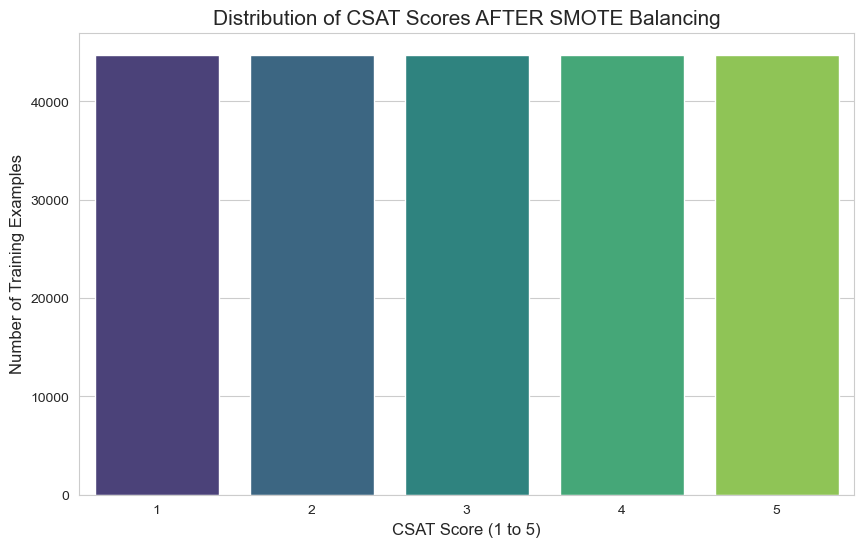

Exact counts for each score category:
1    44758
2    44758
3    44758
4    44758
5    44758
Name: count, dtype: int64


In [48]:
# --- VISUALIZING THE BALANCED DATA ---

# 1. We import our visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Set the visual style and size of the chart
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

# 3. Create a count plot using the new balanced labels (y_train_balanced)
# This chart will show us how many rows exist for each score after SMOTE
sns.countplot(x=y_train_balanced, palette='viridis')

# 4. Add clear labels so anyone can understand the chart
plt.title('Distribution of CSAT Scores AFTER SMOTE Balancing', fontsize=15)
plt.xlabel('CSAT Score (1 to 5)', fontsize=12)
plt.ylabel('Number of Training Examples', fontsize=12)

# 5. Display the final chart
plt.show()

# 6. Print the exact counts to be 100% sure
print("Exact counts for each score category:")
print(y_train_balanced.value_counts().sort_index())

## ***ML Model Implementation***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***